# Laboratorio ConvocaUR — Andres

Workspace personal. **Lee** desde `data/`, **escribe** solo en `salidas/`.

- Catalogo: [../catalogo_datos.md](../catalogo_datos.md)
- Normas del lab: [../README.md](../README.md)
- Docs del sistema: [../../docs/](../../docs/)


## 1. Setup

Carga automatica de datasets. No edites archivos en `data/`.


In [1]:
from collections import Counter
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Raices
PERSONA = "andres"
NB_DIR = Path.cwd()
LAB_DIR = NB_DIR.parent
CONVOCAUR = LAB_DIR.parent

sys.path.insert(0, str(CONVOCAUR / "src"))
sys.path.insert(0, str(LAB_DIR / "_comun"))

from cargar_datos import (
    cargar_todo,
    cargar_profesor,
    guardar_salida,
    salidas_dir,
)

datos = cargar_todo(persona=PERSONA, cargar_json_profesores=False)
SALIDAS = datos["salidas"]

print("Proyecto:", datos["proyecto"])
print("Salidas :", SALIDAS)
print("Docentes:", None if datos["urosario"]["docentes"] is None else len(datos["urosario"]["docentes"]))
print("JSON prof disponibles:", datos["urosario"]["n_json_disponibles"])
print("NLP convocatorias:", len(datos["minciencias"]["nlp_por_convocatoria"]), "disponibles")

Proyecto: D:\Descargas 2\Proyecto SAMSUNG\trabajo\convocaur
Salidas : D:\Descargas 2\Proyecto SAMSUNG\trabajo\convocaur\laboratorio\andres\salidas
Docentes: 613
JSON prof disponibles: 612
NLP convocatorias: 95 disponibles


## 2. Atajos a variables frecuentes


In [2]:
# --- Minciencias ---
listado = datos["minciencias"]["listado"]  # raw scrape; None si falta data/raw/minciencias/ localmente (ver catalogo_datos.md)
convocatorias_processed = datos["minciencias"]["convocatorias_processed"]  # version limpia; no depende del raw
actividades = datos["minciencias"]["actividades"]  # raw; None por el mismo motivo que listado
actividades_processed = datos["minciencias"]["actividades_processed"]
documentos = datos["minciencias"]["documentos"]  # raw; None por el mismo motivo que listado
documentos_processed = datos["minciencias"]["documentos_processed"]

nlp = datos["minciencias"]["nlp_por_convocatoria"]
secciones = datos["minciencias"]["secciones_por_convocatoria"]
elegibilidad = datos["minciencias"]["elegibilidad_por_convocatoria"]

# --- Rosario ---
docentes = datos["urosario"]["docentes"]
sin_cvlac = datos["urosario"]["sin_cvlac"]

print("Listado raw:", "no disponible localmente" if listado is None else f"{len(listado)} filas")
print("Convocatorias processed:", None if convocatorias_processed is None else f"{len(convocatorias_processed)} filas")
print(f"NLP: {len(nlp)} convocatorias | Elegibilidad calculada: {len(elegibilidad)} convocatorias")
if "convocatoria_48" in nlp:
    print("Objetivo 48:", (nlp["convocatoria_48"].get("objetivo") or "")[:240])
    print("Elegibilidad 48:", elegibilidad.get("convocatoria_48", {}).get("veredicto_final"))

# --- Mapa de cobertura: TODO el notebook usa 95 (NLP) como universo de referencia. ---
# convocatorias_processed/actividades_processed/documentos_processed son un SUBCONJUNTO de esas 95
# (listado ⊂ nlp, 14 de 95). elegibilidad ya NO es subconjunto de listado -- se corrio sobre las 95
# completas, asi que elegibilidad = nlp en cantidad (aunque no necesariamente las mismas claves si el
# universo NLP creciera de nuevo sin recalcular elegibilidad para las nuevas).
n_universo = len(nlp)
n_con_listado = convocatorias_processed["numero"].notna().sum() if convocatorias_processed is not None else 0
n_con_elegibilidad = len(elegibilidad)
print()
print(f"Mapa de cobertura -> universo NLP: {n_universo} | con datos de listado (monto/cronograma/documentos): {n_con_listado} | con elegibilidad calculada: {n_con_elegibilidad}")
print("Todas las secciones de abajo reportan sus conteos contra ese mismo universo de 95, no contra denominadores distintos.")


Listado raw: no disponible localmente
Convocatorias processed: 15 filas
NLP: 95 convocatorias | Elegibilidad calculada: 95 convocatorias
Objetivo 48: Contribuir al fortalecimiento de las capacidades territoriales, el conocimiento y el uso sostenible de la biodiversidad, promoviendo soluciones innovadoras y productivas en el marco de la bioeconomía para una Colombia más competitiva, produ
Elegibilidad 48: {'puede_postularse': True, 'modo': 'solo_en_alianza', 'rol_sugerido': 'aliado', 'bloqueantes': [], 'condiciones_a_verificar': ['Acreditación institucional vigente o programas acreditados afines a las líneas temáticas.', 'Experiencia previa en proyectos CTeI en la región SGR, con sumatoria igual o superior al 50% del valor del proyecto.', 'Grupos de investigación categorizados por Minciencias.', 'Posible exigencia de sede o domicilio regional, dado que la sede principal está en Bogotá.'], 'resumen': 'La Universidad del Rosario es una IES privada acreditada y elegible para postularse, pe

## 3. Sugerencias de codigo limpio (ConvocaUR)

1. **No mutar raw/processed.** Si transformas, guarda en `SALIDAS`.
2. **Una responsabilidad por celda** (cargar / transformar / visualizar / exportar).
3. **Nombres claros:** `df_docentes`, `nlp_48`, no `df`, `x`, `tmp2`.
4. **Paths via loader** (`cargar_datos` / `convocaur.paths`), no strings absolutos.
5. **Funciones pequenas** si reutilizas logica (>15 lineas -> `def` o PR a `src/`).
6. **Seeds** si hay muestreo aleatorio.
7. **No subir secretos** ni pegar API keys en el notebook.
8. **Exports reproducibles** con `guardar_salida(PERSONA, "archivo.csv", df)`.
9. Si algo sirve al equipo, muevelo a `src/convocaur/` con PR.


## 4. Tu espacio de trabajo

Ejemplos de partida (borralos si no los usas).


In [3]:
# Ejemplo A: explorar NLP de una convocatoria
conv = "convocatoria_48"
if conv in nlp:
    nlp_48 = nlp[conv]
    print("Alianza obligatoria:", nlp_48.get("alianza_obligatoria"))
    print("N actores:", len(nlp_48.get("actores_elegibles") or []))
    print("N requisitos:", len(nlp_48.get("requisitos") or []))
    print("N criterios:", len(nlp_48.get("criterios_evaluacion") or []))
    print("Financiacion:", nlp_48.get("financiacion"))


Alianza obligatoria: True
N actores: 8
N requisitos: 25
N criterios: 3
Financiacion: {'monto_total_texto': 'Setecientos cuarenta y nueve mil novecientos ochenta y dos millones cuatrocientos treinta mil doscientos noventa y uno ($749.982.430.291)', 'monto_total_cop': 749982430291.0, 'plazo_min_meses': 36, 'plazo_max_meses': 48, 'contrapartida_pct_min': None, 'contrapartida_pct_max': None, 'fuente_recursos': 'Sistema General de Regalías – Asignación para la Ciencia, Tecnología e Innovación, bienio 2025–2026', 'notas': 'El monto total se distribuye equitativamente entre dos modalidades y seis regiones. No se especifica contrapartida.'}


In [4]:
# Ejemplo B: docentes con/sin CvLAC
if docentes is not None and sin_cvlac is not None:
    print("Docentes:", len(docentes))
    print("Sin CvLAC:", len(sin_cvlac))
    perfil_demo = cargar_profesor("ricardo-abello-galvis")
    print(perfil_demo.keys())
    print((perfil_demo.get("cvlac") or {}).get("datos_generales"))
    pass

Docentes: 613
Sin CvLAC: 259
dict_keys(['url', 'nombre', 'cargo_principal', 'email', 'telefono', 'imagen', 'afiliaciones', 'enlaces_externos', 'areas_investigacion', 'perfil_profesional', 'formacion_academica', 'publicaciones', 'total_publicaciones', 'proyectos', 'servicios', 'reconocimientos', 'identidad', 'id', 'facultad_csv', 'cargo_csv', 'cvlac'])
{'nota': 'Par evaluador reconocido por Minciencias.', 'Categoría': 'Investigador Asociado (I) con vigencia hasta la publicación de los resultados de la siguiente convocatoria', 'Nombre': 'Ricardo ABELLO GALVIS', 'Nombre en citaciones': 'ABELLO GALVIS, RICARDO', 'Nacionalidad': 'Colombiana', 'Sexo': 'Femenino'}


In [5]:
# Ejemplo C: guardar un resultado en TU carpeta salidas/
df_demo = convocatorias_processed[["numero", "titulo"]].head(5) if convocatorias_processed is not None else None
if df_demo is not None:
    ruta = guardar_salida(PERSONA, "demo_listado_head.csv", df_demo)
    print("Guardado en", ruta)
pass

Guardado en D:\Descargas 2\Proyecto SAMSUNG\trabajo\convocaur\laboratorio\andres\salidas\demo_listado_head.csv


## 5. Zona libre

Celdas vacias para tu analisis.


## 6. Panorama de convocatorias Minciencias

`data/raw/minciencias/` (incluido el listado original) salio del repo — se movio a un respaldo en Drive (ver [catalogo_datos.md](../catalogo_datos.md)). Usamos `convocatorias_processed` en su lugar: mismo contenido, generado por el pipeline antes del cambio, y no depende de ese raw ausente.

**Nota de alcance:** `convocatorias_processed` solo cubre 14 de las 95 convocatorias del universo NLP (las que vinieron del scrape original). Las secciones 6, 7 y 8 (montos, cronograma, documentos) estan limitadas a esas 14 porque es lo unico que trae esos datos — no es que el resto no tenga esa info, es que nunca se scrapeo para ellas. A partir de la seccion 9 trabajamos sobre las 95 completas.

`total_recursos_texto` viene como string (`"$749.982.430.291"`). Lo parseamos a numero para poder ordenar/agregar.

In [6]:
def parse_monto_cop(texto: str) -> float | None:
    if not isinstance(texto, str):
        return None
    limpio = re.sub(r"[^0-9]", "", texto)
    return float(limpio) if limpio else None

df_convocatorias = convocatorias_processed.copy()
df_convocatorias["monto_cop"] = df_convocatorias["total_recursos_texto"].apply(parse_monto_cop)

n_con_listado = df_convocatorias["numero"].notna().sum()
print(f"Con monto identificado: {df_convocatorias['monto_cop'].notna().sum()} de {len(nlp)} convocatorias del universo (solo {n_con_listado} tienen datos de listado)")
df_convocatorias[["numero", "titulo", "monto_cop", "fecha_apertura_texto"]].sort_values(
    "monto_cop", ascending=False
).head(14)

Con monto identificado: 14 de 95 convocatorias del universo (solo 14 tienen datos de listado)


,numero,titulo,monto_cop,fecha_apertura_texto
1,48.0,"CONVOCATORIA DE LA ASIGNACIÓN PARA LA CIENCIA,...",7.499824e+11,"Martes, Junio 16, 2026"
14,46.0,CONVOCATORIA COLOMBIA INTELIGENTE: INFRAESTRUC...,6.300000e+11,"Martes, Octubre 14, 2025"
8,47.0,AGRO POR LA VIDA Y POR LA TIERRA: GARANTIZAR E...,4.465150e+11,"Jueves, Marzo 12, 2026"
7,49.0,CONVOCATORIA ENERGÍA SOSTENIBLE PARA EL TERRIT...,3.776400e+11,"Jueves, Marzo 12, 2026"
5,975.0,Convocatoria de “Becas para El Cambio” Formaci...,2.795880e+11,"Viernes, Marzo 13, 2026"
13,50.0,CONVOCATORIA EN INVESTIGACIÓN BÁSICA,2.373980e+11,"Martes, Octubre 14, 2025"
11,45.0,FORTALECIMIENTO Y CREACIÓN DE NUEVOS CENTROS E...,2.000000e+11,"Martes, Diciembre 30, 2025"
0,978.0,Convocatoria Fortalecimiento De Capacidades Na...,1.090000e+11,"Miércoles, Julio 15, 2026"
6,52.0,FORTALECIMIENTO DE CAPACIDADES TERRITORIALES E...,1.000000e+11,"Jueves, Marzo 12, 2026"
9,974.0,Convocatoria de “BECAS PARA EL CAMBIO” formaci...,5.515284e+10,"Martes, Febrero 17, 2026"


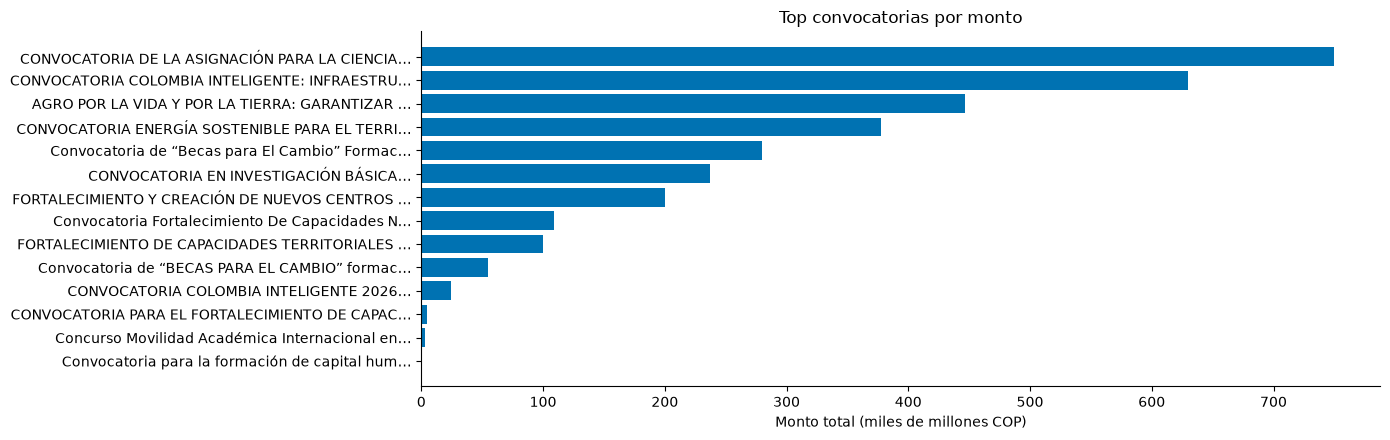

In [7]:
top_montos = df_convocatorias.dropna(subset=["monto_cop"]).sort_values("monto_cop").tail(14).copy()
top_montos["titulo_corto"] = top_montos["titulo"].str.slice(0, 45) + "…"

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.barh(top_montos["titulo_corto"], top_montos["monto_cop"] / 1e9, color="#0072B2")
ax.set_xlabel("Monto total (miles de millones COP)")
ax.set_title("Top convocatorias por monto")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 7. Cronograma y plazos

`actividades_processed` trae hitos por convocatoria (Apertura, Cierre, publicacion de resultados...) como texto en español (`"jueves 27 agosto 2026 04:00 pm"`). Lo parseamos para calcular cuantos dias tiene Rosario entre que abre y cierra cada convocatoria — dato que no habiamos mirado y que importa para priorizar (una convocatoria grande con poco tiempo de preparacion es mas riesgosa que una mediana con margen).

In [8]:
MESES_ES = {
    "enero": 1, "febrero": 2, "marzo": 3, "abril": 4, "mayo": 5, "junio": 6,
    "julio": 7, "agosto": 8, "septiembre": 9, "octubre": 10, "noviembre": 11, "diciembre": 12,
}

def parse_fecha_actividad(texto: str | None) -> pd.Timestamp | None:
    if not isinstance(texto, str):
        return None
    m = re.search(r"(\d{1,2})\s+([a-záéíóúñ]+)\s+(\d{4})", texto.lower())
    if not m:
        return None
    dia, mes_nombre, anio = m.groups()
    mes = MESES_ES.get(mes_nombre)
    if mes is None:
        return None
    try:
        return pd.Timestamp(year=int(anio), month=mes, day=int(dia))
    except ValueError:
        return None

df_actividades = actividades_processed.copy()
df_actividades["fecha"] = df_actividades["fecha_texto"].apply(parse_fecha_actividad)

pivot_fechas = df_actividades[df_actividades["tipo_actividad"].isin(["Apertura", "Cierre"])].pivot_table(
    index="convocatoria_numero", columns="tipo_actividad", values="fecha", aggfunc="first"
)
pivot_fechas["dias_para_preparar"] = (pivot_fechas["Cierre"] - pivot_fechas["Apertura"]).dt.days
pivot_fechas = pivot_fechas.reset_index().rename(columns={"convocatoria_numero": "numero"})

df_cronograma = pivot_fechas.merge(
    convocatorias_processed[["numero", "titulo"]], on="numero", how="left"
).dropna(subset=["dias_para_preparar"]).sort_values("dias_para_preparar").reset_index(drop=True)

guardar_salida(PERSONA, "cronograma_plazos.csv", df_cronograma)
print(f"Convocatorias con Apertura y Cierre identificados: {len(df_cronograma)} de {len(nlp)} convocatorias del universo (solo las del listado traen cronograma)")
df_cronograma[["numero", "titulo", "Apertura", "Cierre", "dias_para_preparar"]].head(14)

Convocatorias con Apertura y Cierre identificados: 14 de 95 convocatorias del universo (solo las del listado traen cronograma)


,numero,titulo,Apertura,Cierre,dias_para_preparar
0,973.0,Convocatoria para la formación de capital huma...,2025-11-20,2025-12-16,26
1,46.0,CONVOCATORIA COLOMBIA INTELIGENTE: INFRAESTRUC...,2025-10-14,2025-11-14,31
2,976.0,CONVOCATORIA COLOMBIA INTELIGENTE 2026,2026-03-13,2026-04-13,31
3,974.0,Convocatoria de “BECAS PARA EL CAMBIO” formaci...,2026-02-17,2026-03-24,35
4,50.0,CONVOCATORIA EN INVESTIGACIÓN BÁSICA,2025-10-14,2025-11-21,38
5,978.0,Convocatoria Fortalecimiento De Capacidades Na...,2026-07-15,2026-08-27,43
6,977.0,Convocatoria de Clasificación y Reconocimiento...,2026-04-08,2026-05-22,44
7,48.0,"CONVOCATORIA DE LA ASIGNACIÓN PARA LA CIENCIA,...",2026-06-16,2026-07-31,45
8,975.0,Convocatoria de “Becas para El Cambio” Formaci...,2026-03-13,2026-04-28,46
9,45.0,FORTALECIMIENTO Y CREACIÓN DE NUEVOS CENTROS E...,2025-12-30,2026-02-20,52


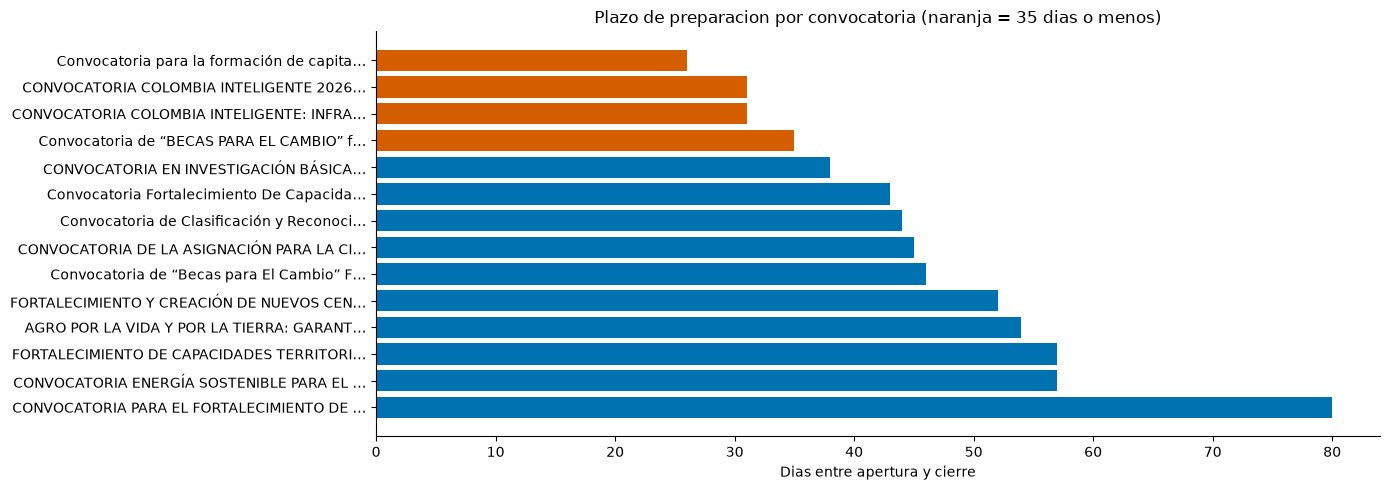

In [9]:
plazos_chart = df_cronograma.copy()
plazos_chart["titulo_corto"] = plazos_chart["titulo"].str.slice(0, 40) + "…"
plazos_chart = plazos_chart.sort_values("dias_para_preparar", ascending=False)

colores = ["#D55E00" if d <= 35 else "#0072B2" for d in plazos_chart["dias_para_preparar"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(plazos_chart["titulo_corto"], plazos_chart["dias_para_preparar"], color=colores)
ax.set_xlabel("Dias entre apertura y cierre")
ax.set_title("Plazo de preparacion por convocatoria (naranja = 35 dias o menos)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 8. Documentos requeridos

`documentos_processed` cubre las mismas 14 convocatorias que el cronograma (mismo scope que `convocatorias_processed`, no las 95 de NLP). Lista TdR, resoluciones, anexos, etc. por convocatoria. Miramos que tipos de documento predominan y cuantos anexos exige cada una — proxy simple de cuanto trabajo documental implica armar la propuesta.

In [10]:
n_conv_con_docs = documentos_processed["convocatoria_numero"].nunique()
print(f"Convocatorias con documentos listados: {n_conv_con_docs} de {len(nlp)} del universo")
print()
print("Tipos de documento:")
print(documentos_processed["tipo_documento"].value_counts())
print()
print("Subtipos de anexo mas comunes:")
print(documentos_processed["subtipo_anexo"].value_counts().head(8))

Convocatorias con documentos listados: 14 de 95 del universo

Tipos de documento:
tipo_documento
anexo                  137
resultado               28
otro                    19
modificacion            16
comunicado              13
terminos_referencia      9
resolucion               8
Name: count, dtype: int64

Subtipos de anexo mas comunes:
subtipo_anexo
otro                    52
tecnico                 19
procedimental           17
poblacion_especifica    15
aval_institucional      12
finanzas                 9
talento_hv               6
apropiacion_social       6
Name: count, dtype: int64


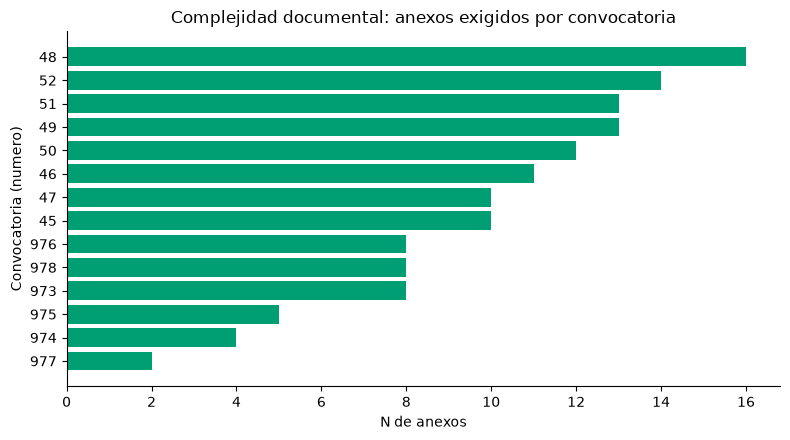

In [11]:
anexos_por_conv = (
    documentos_processed[documentos_processed["tipo_documento"] == "anexo"]
    .groupby("convocatoria_numero")
    .size()
    .sort_values()
)
anexos_por_conv.index = anexos_por_conv.index.astype(int).astype(str)
guardar_salida(PERSONA, "anexos_por_convocatoria.csv", anexos_por_conv.reset_index(name="n_anexos"))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(anexos_por_conv.index, anexos_por_conv.values, color="#009E73")
ax.set_xlabel("N de anexos")
ax.set_ylabel("Convocatoria (numero)")
ax.set_title("Complejidad documental: anexos exigidos por convocatoria")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 9. Panorama NLP + comparativo con elegibilidad

`nlp_por_convocatoria` es el universo de referencia de todo lo que sigue: 95 convocatorias (un companero, Jose, lo expandio — ver el mapa de cobertura en el setup). `elegibilidad_por_convocatoria` ya se corrio para las 95 (antes solo cubria 3; el equipo cerro ese gap despues de mejorar la extraccion de secciones). Por eso separamos en tres vistas:

1. **Panorama general** — todo lo que tiene NLP (alianza obligatoria, montos, requisitos, tipo de convocatoria), sin depender de elegibilidad.
2. **Segmentado por tipo** — las 95 mezclan familias distintas (SGR, Becas, Minciencias regular...) que probablemente tienen patrones de monto/plazo/alianza muy distintos. Clasificamos por palabras clave en titulo/fuente de recursos/objetivo.
3. **Comparativo con elegibilidad** — ahora cubre las 95, no un subconjunto piloto.

Las tres celdas son genericas: si el equipo agrega mas convocatorias al pool NLP, las tres vistas crecen solas sin tocar codigo — ya se demostro al pasar de 3 a 95.


In [12]:
titulos_por_numero = dict(zip(
    convocatorias_processed["numero"].dropna().astype(int).astype(str),
    convocatorias_processed["titulo"],
))

def clasificar_tipo_convocatoria(numero: str, titulo: str | None, fuente_recursos: str | None, objetivo: str | None) -> str:
    texto = " ".join(filter(None, [titulo, fuente_recursos, objetivo])).lower()
    if not texto.strip():
        return "sin_dato"
    if re.search(r"regal|\bsgr\b", texto):
        return "SGR (regalias)"
    if re.search(r"beca|caldas|maestr|doctorad", texto):
        return "Becas / formacion"
    if re.search(r"publindex|revistas cient", texto):
        return "Publindex"
    if re.search(r"movilidad", texto):
        return "Movilidad academica"
    if re.search(r"minciencias|ministerio de ciencia", texto):
        return "Minciencias (regular)"
    return "sin_clasificar"

filas_panorama = []
for conv_id, info in nlp.items():
    fin = info.get("financiacion") or {}
    numero = conv_id.replace("convocatoria_", "")
    filas_panorama.append({
        "convocatoria": conv_id,
        "tipo_convocatoria": clasificar_tipo_convocatoria(
            numero, titulos_por_numero.get(numero), fin.get("fuente_recursos"), info.get("objetivo")
        ),
        "alianza_obligatoria": info.get("alianza_obligatoria"),
        "n_actores": len(info.get("actores_elegibles") or []),
        "n_requisitos": len(info.get("requisitos") or []),
        "monto_total_cop": fin.get("monto_total_cop"),
        "tiene_elegibilidad": conv_id in elegibilidad,
    })

df_panorama_nlp = pd.DataFrame(filas_panorama).sort_values("monto_total_cop", ascending=False).reset_index(drop=True)
guardar_salida(PERSONA, "panorama_nlp_todas.csv", df_panorama_nlp)

n_con_alianza = df_panorama_nlp["alianza_obligatoria"].sum()
n_con_dato = df_panorama_nlp["alianza_obligatoria"].notna().sum()
print(f"NLP procesado: {len(df_panorama_nlp)} convocatorias (universo completo).")
print(f"Con alianza obligatoria: {n_con_alianza} de {n_con_dato} con ese dato.")
print(f"Con elegibilidad calculada: {df_panorama_nlp['tiene_elegibilidad'].sum()} de {len(df_panorama_nlp)}.")
df_panorama_nlp.head(14)

NLP procesado: 95 convocatorias (universo completo).
Con alianza obligatoria: 48 de 61 con ese dato.
Con elegibilidad calculada: 95 de 95.


,convocatoria,tipo_convocatoria,alianza_obligatoria,n_actores,n_requisitos,monto_total_cop,tiene_elegibilidad
0,convocatoria_48,SGR (regalias),True,8,25,7.499824e+11,True
1,convocatoria_46,SGR (regalias),True,8,17,6.300000e+11,True
2,convocatoria_37,SGR (regalias),True,6,10,5.000000e+11,True
3,convocatoria_44,SGR (regalias),True,2,11,4.820000e+11,True
4,convocatoria_47,SGR (regalias),True,5,16,4.465150e+11,True
5,convocatoria_35,SGR (regalias),None,2,23,4.000000e+11,True
6,convocatoria_49,SGR (regalias),True,3,22,3.776400e+11,True
7,convocatoria_975,Becas / formacion,None,3,23,3.680170e+11,True
8,convocatoria_36,SGR (regalias),True,3,24,3.650000e+11,True
9,convocatoria_34,sin_clasificar,None,0,25,3.588888e+11,True


In [13]:
print("Convocatorias por tipo (95 totales):")
print(df_panorama_nlp["tipo_convocatoria"].value_counts())
print()

resumen_por_tipo = df_panorama_nlp.groupby("tipo_convocatoria").agg(
    n_convocatorias=("convocatoria", "count"),
    monto_promedio_cop=("monto_total_cop", "mean"),
    pct_alianza_obligatoria=("alianza_obligatoria", "mean"),
).sort_values("n_convocatorias", ascending=False)

guardar_salida(PERSONA, "panorama_por_tipo_convocatoria.csv", resumen_por_tipo.reset_index())
resumen_por_tipo

Convocatorias por tipo (95 totales):
tipo_convocatoria
SGR (regalias)           27
sin_clasificar           25
Becas / formacion        17
Minciencias (regular)    15
Publindex                 4
sin_dato                  4
Movilidad academica       3
Name: count, dtype: int64



,n_convocatorias,monto_promedio_cop,pct_alianza_obligatoria
tipo_convocatoria,,,
SGR (regalias),27,2.153536e+11,0.826087
sin_clasificar,25,5.837375e+10,0.571429
Becas / formacion,17,3.688413e+10,0.909091
Minciencias (regular),15,1.859344e+10,0.9
Publindex,4,2.874466e+09,0.0
sin_dato,4,NaN,NaN
Movilidad academica,3,1.261920e+10,1.0


In [14]:
filas_comparativo = []
for conv_id in elegibilidad:
    info = nlp.get(conv_id, {})
    fin = info.get("financiacion") or {}
    veredicto = elegibilidad[conv_id].get("veredicto_final", {})
    filas_comparativo.append({
        "convocatoria": conv_id,
        "alianza_obligatoria": info.get("alianza_obligatoria"),
        "n_actores": len(info.get("actores_elegibles") or []),
        "n_requisitos": len(info.get("requisitos") or []),
        "n_criterios": len(info.get("criterios_evaluacion") or []),
        "monto_total_cop": fin.get("monto_total_cop"),
        "plazo_max_meses": fin.get("plazo_max_meses"),
        "puede_postularse": veredicto.get("puede_postularse"),
        "modo": veredicto.get("modo"),
        "rol_sugerido": veredicto.get("rol_sugerido"),
    })

df_comparativo = pd.DataFrame(filas_comparativo).sort_values("convocatoria").reset_index(drop=True)
guardar_salida(PERSONA, "comparativo_nlp_elegibilidad.csv", df_comparativo)
print(f"{len(df_comparativo)} de {len(nlp)} convocatorias con NLP tienen elegibilidad calculada.")
df_comparativo

95 de 95 convocatorias con NLP tienen elegibilidad calculada.


,convocatoria,alianza_obligatoria,n_actores,n_requisitos,n_criterios,monto_total_cop,plazo_max_meses,puede_postularse,modo,rol_sugerido
0,convocatoria_1041,None,2,10,0,NaN,NaN,True,elegible_con_condiciones,ejecutora
1,convocatoria_1042,None,0,5,5,NaN,8.0,True,elegible_con_condiciones,ejecutora
2,convocatoria_1044,None,0,15,5,NaN,6.0,True,elegible_con_condiciones,proponente
3,convocatoria_1047,None,0,9,3,7.216800e+08,12.0,True,solo_en_alianza,ejecutora
4,convocatoria_1049,True,5,25,0,NaN,NaN,True,solo_en_alianza,ejecutora
...,...,...,...,...,...,...,...,...,...,...
90,convocatoria_974,None,2,15,5,5.515284e+10,NaN,False,no_elegible,NaN
91,convocatoria_975,None,3,23,4,3.680170e+11,48.0,False,no_elegible,NaN
92,convocatoria_976,True,4,15,11,2.400000e+10,14.0,True,solo_en_alianza,ejecutora
93,convocatoria_977,False,1,9,18,NaN,NaN,False,no_elegible,NaN


## 10. Requisitos, criterios y financiacion en detalle

Hasta ahora solo contamos cuantos requisitos/criterios tiene cada convocatoria (seccion 9). Aqui miramos el contenido: que tipo de requisitos predominan, que tan obligatorios son, y como se ve la financiacion (plazo de ejecucion, contrapartida) en el conjunto de las 95 convocatorias con NLP.

In [15]:
tipo_requisito_counter = Counter()
severidad_counter = Counter()
for info in nlp.values():
    for r in info.get("requisitos") or []:
        tipo_requisito_counter[r.get("tipo") or "sin_tipo"] += 1
        severidad_counter[r.get("severidad") or "sin_dato"] += 1

df_tipo_requisito = pd.DataFrame(tipo_requisito_counter.most_common(), columns=["tipo", "n_requisitos"])
guardar_salida(PERSONA, "requisitos_por_tipo.csv", df_tipo_requisito)

print("Requisitos por tipo (todas las convocatorias NLP):")
print(df_tipo_requisito.to_string(index=False))
print()
print("Requisitos por severidad:")
print(pd.Series(severidad_counter).sort_values(ascending=False))

Requisitos por tipo (todas las convocatorias NLP):
       tipo  n_requisitos
 documental           792
habilitante           291
    tecnico           151
       otro           114
 financiero           102
    alianza            43

Requisitos por severidad:
obligatorio    1421
deseable         72
dtype: int64


In [16]:
filas_financiacion = []
for conv_id, info in nlp.items():
    fin = info.get("financiacion") or {}
    filas_financiacion.append({
        "convocatoria": conv_id,
        "plazo_max_meses": fin.get("plazo_max_meses"),
        "contrapartida_pct_min": fin.get("contrapartida_pct_min"),
        "contrapartida_pct_max": fin.get("contrapartida_pct_max"),
    })

df_financiacion = pd.DataFrame(filas_financiacion)
guardar_salida(PERSONA, "financiacion_detalle.csv", df_financiacion)

n_con_plazo = df_financiacion["plazo_max_meses"].notna().sum()
n_con_contrapartida = df_financiacion[["contrapartida_pct_min", "contrapartida_pct_max"]].notna().any(axis=1).sum()
print(f"Con plazo_max_meses: {n_con_plazo} de {len(df_financiacion)}")
print(f"Con contrapartida especificada: {n_con_contrapartida} de {len(df_financiacion)}")
print()
print(df_financiacion["plazo_max_meses"].describe())

Con plazo_max_meses: 70 de 95
Con contrapartida especificada: 26 de 95

count    70.000000
mean     31.442857
std      18.404186
min       5.000000
25%      15.000000
50%      36.000000
75%      36.000000
max      96.000000
Name: plazo_max_meses, dtype: float64


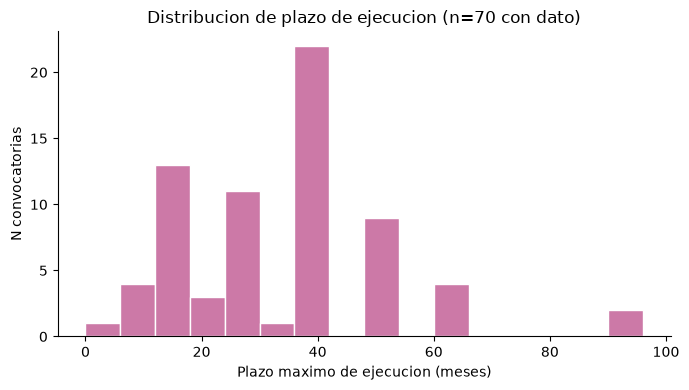

In [17]:
plazos_validos = df_financiacion["plazo_max_meses"].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(plazos_validos, bins=range(0, int(plazos_validos.max()) + 6, 6), color="#CC79A7", edgecolor="white")
ax.set_xlabel("Plazo maximo de ejecucion (meses)")
ax.set_ylabel("N convocatorias")
ax.set_title(f"Distribucion de plazo de ejecucion (n={len(plazos_validos)} con dato)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 11. Calidad de las extracciones NLP

Con 95 convocatorias procesadas, no todas tienen la misma calidad de extraccion — algunas quedaron con varios campos vacios (quiza el TdR no tenia todas las secciones esperadas, o la extraccion no encontro contenido). Antes de confiar en matching o elegibilidad sobre una convocatoria puntual, vale la pena chequear que tan completa quedo su NLP.

In [18]:
CAMPOS_CLAVE_NLP = ["objetivo", "actores_elegibles", "lineas_tematicas", "requisitos", "criterios_evaluacion", "financiacion"]

def campo_poblado(valor) -> bool:
    if valor is None or valor == "" or valor == [] or valor == {}:
        return False
    if isinstance(valor, dict):
        return any(v is not None for v in valor.values())
    return True

filas_calidad = []
for conv_id, info in nlp.items():
    poblados = sum(campo_poblado(info.get(c)) for c in CAMPOS_CLAVE_NLP)
    filas_calidad.append({
        "convocatoria": conv_id,
        "campos_poblados": poblados,
        "completitud": f"{poblados}/{len(CAMPOS_CLAVE_NLP)}",
    })

df_calidad_nlp = pd.DataFrame(filas_calidad).sort_values("campos_poblados").reset_index(drop=True)
guardar_salida(PERSONA, "calidad_extracciones_nlp.csv", df_calidad_nlp)

print("Distribucion de campos poblados (de 6 posibles):")
print(df_calidad_nlp["campos_poblados"].value_counts().sort_index())
print()
n_vacias = (df_calidad_nlp["campos_poblados"] == 0).sum()
n_pobres = (df_calidad_nlp["campos_poblados"] <= 2).sum()
print(f"Completamente vacias (0/6): {n_vacias} de {len(df_calidad_nlp)}")
print(f"Extraccion pobre (<=2/6): {n_pobres} de {len(df_calidad_nlp)} — no confiar en matching/elegibilidad sobre estas sin revisar a mano")


Distribucion de campos poblados (de 6 posibles):
campos_poblados
0     1
2     1
3     4
4     5
5    19
6    65
Name: count, dtype: int64

Completamente vacias (0/6): 1 de 95
Extraccion pobre (<=2/6): 2 de 95 — no confiar en matching/elegibilidad sobre estas sin revisar a mano


## 12. Capacidad Rosario: perfiles completos, cobertura CvLAC y categorias

Cargamos los 612 JSON de `json_profesores/` (~16 MB, liviano) para extraer facultad, categoria CvLAC y un texto de perfil (`areas_investigacion` + `lineas_investigacion`) que reutilizamos en la seccion 13. No se guarda todo en `datos`, solo lo necesario en `df_perfiles`.

In [19]:
STOPWORDS_ES = {
    "para", "con", "del", "los", "las", "que", "como", "entre", "sobre",
    "desde", "hacia", "este", "esta", "estos", "estas", "mediante", "dentro",
}

def tokenizar(texto: str | None) -> list[str]:
    return [w for w in re.findall(r"[a-záéíóúñ]{6,}", (texto or "").lower()) if w not in STOPWORDS_ES]

def categoria_simple(categoria: str | None) -> str | None:
    if not isinstance(categoria, str):
        return None
    m = re.search(r"Investigador\s+(Junior|Asociado|Senior|Em[eé]rito)", categoria)
    return m.group(0) if m else categoria[:40]

registros_perfiles = []
for _, fila in docentes.iterrows():
    try:
        perfil = cargar_profesor(fila["id"])
    except FileNotFoundError:
        continue
    cv = perfil.get("cvlac")
    texto = " ".join(perfil.get("areas_investigacion") or [])
    if cv:
        texto += " " + " ".join(cv.get("lineas_investigacion") or [])
    registros_perfiles.append({
        "id": fila["id"],
        "facultad": fila["facultad"],
        "tiene_cvlac": cv is not None,
        "categoria_cvlac": categoria_simple(((cv or {}).get("datos_generales") or {}).get("Categoría")),
        "n_areas_investigacion": len(perfil.get("areas_investigacion") or []),
        "n_publicaciones": perfil.get("total_publicaciones") or 0,
        "texto_perfil": texto,
    })

df_perfiles = pd.DataFrame(registros_perfiles)
df_perfiles["tokens_perfil"] = df_perfiles["texto_perfil"].apply(tokenizar)
print(f"Perfiles cargados: {len(df_perfiles)}")
df_perfiles.drop(columns=["texto_perfil", "tokens_perfil"]).head(14)

Perfiles cargados: 612


,id,facultad,tiene_cvlac,categoria_cvlac,n_areas_investigacion,n_publicaciones
0,ricardo-abello-galvis,Facultad de Jurisprudencia,True,Investigador Asociado,8,71
1,yeny-yasbleidy-acosta-ampudia,Escuela de Medicina y Ciencias de la Salud,True,Investigador Senior,3,83
2,paula-maria-acosta-arango,Facultad de Creación,False,NaN,4,0
3,dennis-elena-acosta-machado,Escuela de Medicina y Ciencias de la Salud,False,NaN,0,0
4,patricia-acosta-restrepo,"Escuela de Estudios Sociales, Políticos e Inte...",True,NaN,5,9
5,susana-margarita-aguilar-cabeza,Escuela de Medicina y Ciencias de la Salud,False,NaN,0,0
6,beira-andrea-aguilar-rubiano,"Escuela de Estudios Sociales, Políticos e Inte...",True,NaN,5,11
7,angie-tatiana-aguilar-suarez,Escuela de Medicina y Ciencias de la Salud,False,NaN,0,0
8,nathalia-aguilera-leal,Escuela de Medicina y Ciencias de la Salud,False,NaN,4,0
9,sara-isabel-aguilera-martinez,Escuela de Medicina y Ciencias de la Salud,False,NaN,3,0


In [20]:
print("Categoria CvLAC (simplificada):")
print(df_perfiles["categoria_cvlac"].value_counts(dropna=False))
print()

tabla_cobertura = pd.crosstab(df_perfiles["facultad"], df_perfiles["tiene_cvlac"])
guardar_salida(PERSONA, "cobertura_cvlac_por_facultad.csv", tabla_cobertura.reset_index())
tabla_cobertura

Categoria CvLAC (simplificada):
categoria_cvlac
NaN                      424
Investigador Junior       86
Investigador Senior       54
Investigador Asociado     46
Investigador Emérito       2
Name: count, dtype: int64



tiene_cvlac,False,True
facultad,,
Decanatura del Medio Universitario,7,2
Editorial de la Universidad del Rosario,0,1
Escuela de Administración,16,20
Escuela de Ciencias e Ingeniería,15,35
"Escuela de Estudios Sociales, Políticos e Internacionales",13,48
Escuela de Medicina y Ciencias de la Salud,154,181
Facultad de Creación,23,7
Facultad de Economía,22,12
Facultad de Jurisprudencia,8,42


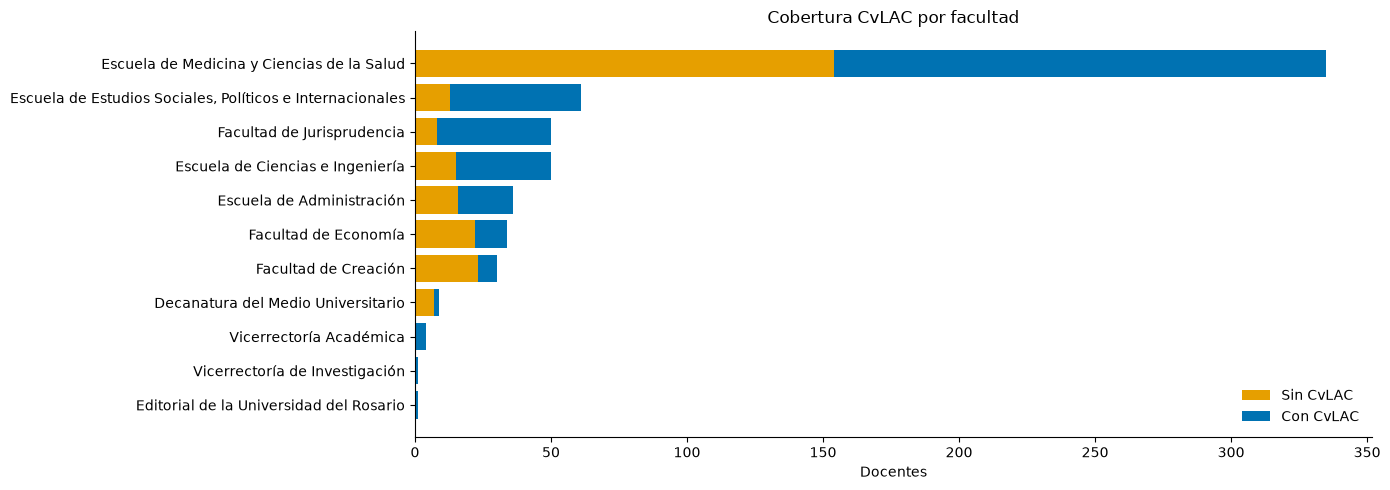

In [21]:
tabla_ordenada = tabla_cobertura.loc[tabla_cobertura.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(tabla_ordenada.index, tabla_ordenada[False], color="#E69F00", label="Sin CvLAC")
ax.barh(tabla_ordenada.index, tabla_ordenada[True], left=tabla_ordenada[False], color="#0072B2", label="Con CvLAC")
ax.set_xlabel("Docentes")
ax.set_title("Cobertura CvLAC por facultad")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 13. Prototipo de matching por palabras clave (anticipo del roadmap de embeddings)

Baseline **muy simple** antes de construir embeddings (ver [roadmap_matching.md](../../docs/roadmap_matching.md), pasos 1-3). Nota: Jose ya construyo un matching real con embeddings (OpenRouter) + TF-IDF en `laboratorio/jose/matching/` (ver su `DECISIONES.md`) — esto que sigue es un baseline propio, mas simple y sin costo de API, util como punto de comparacion.

Sacamos las palabras mas frecuentes del `objetivo` + `lineas_tematicas` de cada convocatoria y contamos cuantas aparecen en el texto de perfil (`areas_investigacion` + `lineas_investigacion`) de cada docente.

Reglas que ya aplicamos siguiendo el roadmap:

1. **No rankear convocatorias no elegibles** — solo procesamos convocatorias con elegibilidad calculada y `puede_postularse=True` (paso 1 del roadmap). Ahora que elegibilidad cubre las 95, esto corre sobre 61 convocatorias (antes 3) sin tocar codigo — la genericidad de la seccion 9 se demostro sola.
2. **Score con senal de evidencia** — +1 si el docente tiene CvLAC, +1 si su categoria es Senior/Asociado (mejor evidencia que Junior/sin categoria).
3. **Cobertura minima** — marcamos `equipo_suficiente = "parcial"` si hay al menos 1 Senior/Asociado en el top-15 (paso 3 del roadmap); si no, `"insuficiente"`. Sobre las 61 convocatorias elegibles: 57 salen `parcial` y 4 `insuficiente`.

Limitaciones conocidas (por diseno, no bugs): coincidencia por palabra suelta sin semantica, no distingue sinonimos, no usa grupos A1/A/B/C (aun no tabulados), no descarta las convocatorias con extraccion NLP pobre (ver seccion 11). Sirve como shortlist inicial a revisar a mano, no como ranking final.


In [22]:
CATEGORIAS_FUERTES = {"Investigador Senior", "Investigador Asociado"}

def extraer_palabras_clave(info_conv: dict, top_n: int = 20) -> set[str]:
    texto = (info_conv.get("objetivo") or "") + " " + " ".join(
        lt.get("nombre") or "" for lt in info_conv.get("lineas_tematicas") or []
    )
    return {w for w, _ in Counter(tokenizar(texto)).most_common(top_n)}

In [23]:
def construir_shortlist(conv_id: str, top_n: int = 15) -> tuple[set[str], pd.DataFrame]:
    palabras_clave = extraer_palabras_clave(nlp[conv_id])
    df = df_perfiles.copy()
    df["coincidencias"] = df["tokens_perfil"].apply(lambda tokens: sorted(palabras_clave & set(tokens)))
    df["n_coincidencias"] = df["coincidencias"].apply(len)
    df["score"] = (
        df["n_coincidencias"]
        + df["tiene_cvlac"].astype(int)
        + df["categoria_cvlac"].isin(CATEGORIAS_FUERTES).astype(int)
    )
    candidatos = (
        df[df["n_coincidencias"] > 0]
        .sort_values("score", ascending=False)
        .drop(columns=["texto_perfil", "tokens_perfil"])
        .reset_index(drop=True)
    )
    return palabras_clave, candidatos.head(top_n)

In [24]:
resumen_cobertura = []
shortlists_por_convocatoria = {}

convocatorias_elegibles = [
    conv_id for conv_id in elegibilidad
    if elegibilidad[conv_id].get("veredicto_final", {}).get("puede_postularse") and conv_id in nlp
]
print(f"Elegibilidad calculada: {len(elegibilidad)} de {len(nlp)} convocatorias con NLP.")
print(f"De esas, elegibles para Rosario: {len(convocatorias_elegibles)}.")

for conv_id in convocatorias_elegibles:
    veredicto = elegibilidad[conv_id]["veredicto_final"]
    palabras_clave, top_candidatos = construir_shortlist(conv_id)
    shortlists_por_convocatoria[conv_id] = top_candidatos
    guardar_salida(PERSONA, f"shortlist_keyword_{conv_id}.csv", top_candidatos)

    tiene_cobertura_fuerte = top_candidatos["categoria_cvlac"].isin(CATEGORIAS_FUERTES).any()
    resumen_cobertura.append({
        "convocatoria": conv_id,
        "modo_elegibilidad": veredicto.get("modo"),
        "n_palabras_clave": len(palabras_clave),
        "n_candidatos_top": len(top_candidatos),
        "tiene_senior_o_asociado_en_top": tiene_cobertura_fuerte,
        "equipo_suficiente": "parcial" if tiene_cobertura_fuerte else "insuficiente",
    })

df_resumen_cobertura = pd.DataFrame(resumen_cobertura)
guardar_salida(PERSONA, "resumen_cobertura.csv", df_resumen_cobertura)
df_resumen_cobertura

Elegibilidad calculada: 95 de 95 convocatorias con NLP.
De esas, elegibles para Rosario: 61.


,convocatoria,modo_elegibilidad,n_palabras_clave,n_candidatos_top,tiene_senior_o_asociado_en_top,equipo_suficiente
0,convocatoria_1041,elegible_con_condiciones,20,15,True,parcial
1,convocatoria_1042,elegible_con_condiciones,0,0,False,insuficiente
2,convocatoria_1044,elegible_con_condiciones,0,0,False,insuficiente
3,convocatoria_1047,solo_en_alianza,20,15,True,parcial
4,convocatoria_1049,solo_en_alianza,18,15,True,parcial
...,...,...,...,...,...,...
56,convocatoria_970,solo_en_alianza,20,8,True,parcial
57,convocatoria_971,solo_en_alianza,20,15,True,parcial
58,convocatoria_972,solo_en_alianza,20,15,True,parcial
59,convocatoria_976,solo_en_alianza,20,15,True,parcial


In [25]:
# Detalle de una convocatoria puntual (cambia la clave para inspeccionar otra)
shortlists_por_convocatoria["convocatoria_48"].head(14)

,id,facultad,tiene_cvlac,categoria_cvlac,n_areas_investigacion,n_publicaciones,coincidencias,n_coincidencias,score
0,pedro-mario-wightman-rojas,Escuela de Ciencias e Ingeniería,True,Investigador Senior,8,50,"[colombia, desarrollo, productiva]",3,5
1,jose-mauricio-sanabria-rangel,Escuela de Administración,True,Investigador Asociado,5,20,"[colombia, investigación, productiva]",3,5
2,diana-rocio-bernal-camargo,Facultad de Jurisprudencia,True,Investigador Senior,4,38,"[desarrollo, investigación]",2,4
3,clara-ines-pardo-martinez,Escuela de Administración,True,Investigador Senior,5,65,"[desarrollo, sostenible]",2,4
4,lina-marcela-munoz-avila,Facultad de Jurisprudencia,True,Investigador Asociado,3,38,"[desarrollo, sostenible]",2,4
5,juan-alberto-castillo-martinez,Escuela de Medicina y Ciencias de la Salud,True,Investigador Senior,2,78,"[conocimiento, desarrollo]",2,4
6,juan-miguel-gallego-acevedo,Vicerrectoría de Investigación,True,Investigador Senior,3,59,"[conocimiento, desarrollo]",2,4
7,angela-del-pilar-santamaria-chavarro,Vicerrectoría Académica,True,Investigador Senior,4,47,"[colombia, investigación]",2,4
8,luis-hernando-gutierrez-ramirez,Facultad de Economía,True,Investigador Asociado,4,48,[servicios],1,3
9,juana-laura-victoria-garcia-matamoros,Facultad de Jurisprudencia,True,Investigador Asociado,3,45,[desarrollo],1,3


## 14. Hallazgos y proximos pasos

- **Montos:** la convocatoria 48 (SGR — biodiversidad y bioeconomia) concentra el mayor monto (~$750.000 millones COP), seguida por Colombia Inteligente - Infraestructura IA (~$630.000 millones) y Agro por la Vida y por la Tierra (~$446.000 millones). Ver grafico seccion 6. (`data/raw/minciencias/` salio del repo; esta tabla usa `convocatorias_processed`, que cubre 14 de las 95 del universo — las unicas que vinieron del scrape original.)
- **Cronograma:** el plazo entre apertura y cierre varia bastante — desde 26 dias (convocatoria 973, formacion capital humano Cundinamarca) hasta 80 dias (convocatoria 51, Cordoba). Ver seccion 7.
- **Documentos:** la convocatoria 48 exige el mayor numero de anexos (16); varias SGR piden entre 10-14. Es un proxy simple de carga documental para priorizar. Ver seccion 8.
- **Elegibilidad — gap cerrado:** el equipo corrio elegibilidad sobre las 95 convocatorias del pool NLP (antes solo cubria 3: 45, 48, 976). De las 95, **61 dan `puede_postularse=True`** y 34 `no_elegible`. Por modo: 38 `solo_en_alianza`, 12 `sola`, 8 `elegible_con_condiciones`, 2 `solo_como_aliado`, 1 `puede_sola_o_alianza`.
- **Requisitos y financiacion (seccion 10):** el tipo de requisito mas comun es `documental` (792 ocurrencias), seguido de `habilitante` (291), `tecnico` (151), `otro` (114), `financiero` (102) y `alianza` (43); la gran mayoria es `obligatorio` (1421) vs `deseable` (72) — poco margen para incumplir requisitos. El plazo de ejecucion tipico ronda los 31 meses (rango 5-96), ahora con dato en 70/95 convocatorias (antes 49/95), y 26/95 especifican contrapartida (antes 17/95).
- **Calidad de extracciones NLP (seccion 11) — el hallazgo que mas cambio:** de las 95 convocatorias con NLP, solo **1 sigue completamente vacia** (`convocatoria_942`, 0/6) y **1 mas con extraccion pobre** (`convocatoria_39`, 2/6) — antes eran 22 vacias y 33 con <=2 campos poblados. **65 de 95 estan realmente completas (6/6).** Nota metodologica: se corrigio `campo_poblado()` para que un `financiacion` con los 8 sub-campos en `None` ya no cuente como "poblado" solo por ser un dict no vacio (afectaba a 5 convocatorias, por eso el numero de 6/6 bajo de 66 a 65 tras el fix).
- **Cobertura CvLAC:** 353/612 docentes con CvLAC; Medicina concentra el mayor volumen absoluto pero tambien el mayor numero de docentes sin CvLAC (ver grafico seccion 12).
- **Matching por palabras clave (este notebook):** ahora corre sobre las 61 convocatorias elegibles (antes 3 — escalo solo, sin tocar codigo, tal como estaba disenado). Resultado: **57 `equipo_suficiente="parcial"`, 4 `"insuficiente"`** (sin ningun Senior/Asociado en el top-15) — nunca sale "suficiente" a proposito: falta cruzar con grupos A1/A/B/C y sede regional, que todavia no existen en los datos.
- **Matching real con embeddings:** Jose construyo un sistema hibrido (embeddings OpenRouter + TF-IDF, boost por CvLAC/categoria) en `laboratorio/jose/matching/`, con web explorer en `laboratorio/jose/web/`. No se verifico en esta pasada si ya lo escalo a las 95/61 convocatorias actuales — pendiente confirmar con el. Requiere `scikit-learn`, `fastapi`, `uvicorn` (no estan en `requirements.txt` todavia).
- **Siguiente paso natural:** los dos pendientes que este notebook tenia (filtrar por calidad antes de correr elegibilidad, y correr elegibilidad sobre el resto) ya se resolvieron. Lo que sigue: extender el matching real de Jose (o este baseline) al pool completo de 61 elegibles, agregar `scikit-learn`/`fastapi`/`uvicorn` a `requirements.txt`, e investigar aparte los 2 casos residuales de extraccion pobre (`convocatoria_39`, `convocatoria_942`).
